# Customer Intelligence and Segmentation System Using Unsupervised Learning

## Business Problem

### An online retail company has thousands of customers.

### Management wants answers:

- Who are VIP customers?
- Who are loyal customers?
- Who are inactive customers?
- Who are risky customers?
- Which customers should receive discounts?
- Which customers generate maximum revenue?

- No labels are available.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df=pd.read_excel('Online_Retail.xlsx')
df.shape

(541909, 8)

In [9]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Features Meaning
| Column      | Meaning          |
| ----------- | ---------------- |
| InvoiceNo   | Transaction ID   |
| StockCode   | Product ID       |
| Description | Product Name     |
| Quantity    | Number of Items  |
| InvoiceDate | Purchase Date    |
| UnitPrice   | Price per Item   |
| CustomerID  | Customer ID      |
| Country     | Customer Country |


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [11]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [12]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(5268)

In [14]:
df[df['CustomerID'].isnull()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


In [15]:
df = df.dropna(subset=['CustomerID'])

In [16]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [17]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [18]:
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [19]:
# checking how many negative values exist.
print("Negative Quantity:", (df['Quantity'] < 0).sum())

print("Negative UnitPrice:", (df['UnitPrice'] < 0).sum())

Negative Quantity: 8905
Negative UnitPrice: 0


In [20]:
df[df['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [21]:
df[df['Quantity'] < 0][['InvoiceNo','Quantity','CustomerID']].head(10)

,InvoiceNo,Quantity,CustomerID
141,C536379,-1,14527.0
154,C536383,-1,15311.0
235,C536391,-12,17548.0
236,C536391,-24,17548.0
237,C536391,-24,17548.0
238,C536391,-24,17548.0
239,C536391,-12,17548.0
240,C536391,-12,17548.0
241,C536391,-24,17548.0
939,C536506,-6,17897.0


In [22]:
# Keeping only successful purchases
df = df[df['Quantity'] > 0]

# Verify
print("Negative Quantity:", (df['Quantity'] < 0).sum())

Negative Quantity: 0


### Negative quantities represented cancelled or returned orders (InvoiceNo starts with 'C'). Since the objective was customer purchase segmentation, I retained only successful transactions and removed returns.

In [23]:
print("Shape:", df.shape)

print("Duplicates:", df.duplicated().sum())

Shape: (397924, 8)
Duplicates: 5192


In [24]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2010-12-01 11:49:00,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,2010-12-01 11:49:00,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,2010-12-01 11:49:00,3.75,17920.0,United Kingdom


## What df.duplicated() finds

### It finds rows where every column is identical.

### For example:

| InvoiceNo | StockCode | Quantity | CustomerID |
| --------- | --------- | -------- | ---------- |
| 536409    | 21866     | 1        | 17908      |
| 536409    | 21866     | 1        | 17908      |

### Everything is the same.

### This is usually:

- Data entry duplication

- ETL issue

- System export issue

In [25]:
df[df.duplicated(keep=False)].sort_values(
    ['InvoiceNo','StockCode']
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


## Reason:

### If I keep them:

- Frequency becomes inflated
- Revenue becomes inflated
- RFM values become incorrect
- Clusters become misleading

In [26]:
df = df.drop_duplicates()

In [27]:
print("Duplicates:", df.duplicated().sum())
print("Shape:", df.shape)

Duplicates: 0
Shape: (392732, 8)


### I removed exact duplicate records because they artificially inflate purchase frequency and spending metrics, leading to biased customer clusters.

In [28]:
df.shape

(392732, 8)

In [29]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,392732.0,13.153718,1.0,2.0,6.0,12.0,80995.0,181.58842
InvoiceDate,392732,2011-07-10 19:15:24.576301,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392732.0,3.125596,0.0,1.25,1.95,3.75,8142.75,22.240725
CustomerID,392732.0,15287.734822,12346.0,13955.0,15150.0,16791.0,18287.0,1713.567773


In [30]:
print("Zero UnitPrice:", (df['UnitPrice'] == 0).sum())

Zero UnitPrice: 40


#### A price of 0 can mean:

- Free sample
- Promotional gift
- Data entry issue
- Missing price

- We need to know which one.

In [31]:
df[df['UnitPrice'] == 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [32]:
df[df['UnitPrice'] == 0][['InvoiceNo','Description','Quantity','CustomerID']]

,InvoiceNo,Description,Quantity,CustomerID
9302,537197,ROUND CAKE TIN VINTAGE GREEN,1,12647.0
33576,539263,ADVENT CALENDAR GINGHAM SACK,4,16560.0
40089,539722,REGENCY CAKESTAND 3 TIER,10,14911.0
47068,540372,PAPER BUNTING RETROSPOT,24,13081.0
47070,540372,PLASTERS IN TIN SKULLS,24,13081.0
56674,541109,ORGANISER WOOD ANTIQUE WHITE,1,15107.0
86789,543599,FAIRY CAKES NOTEBOOK A6 SIZE,16,17560.0
130188,547417,CERAMIC BOWL WITH LOVE HEART DESIGN,36,13239.0
139453,548318,MINI CAKE STAND HANGING STRAWBERY,5,13113.0
145208,548871,HEART GARLAND RUSTIC PADDED,2,14410.0


In [33]:
df = df[df['UnitPrice'] > 0]

### I removed transactions with UnitPrice equal to zero because they represented free or promotional items and did not contribute to customer monetary value, which was a key feature in RFM-based customer segmentation.

In [34]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,392692.0,13.119702,1.0,2.0,6.0,12.0,80995.0,180.492832
InvoiceDate,392692,2011-07-10 19:13:07.771892,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392692.0,3.125914,0.001,1.25,1.95,3.75,8142.75,22.241836
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549


<Axes: >

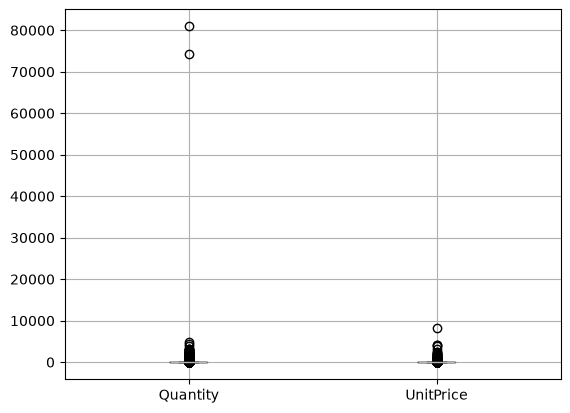

In [35]:
df[['Quantity','UnitPrice']].boxplot()

In [36]:
#Perfect- boxplot confirms:

#Quantity max = 80995
#Quantity 75% = 12

#UnitPrice max = 8142.75
#UnitPrice 75% = 3.75

#we have extreme outliers.

In [37]:
# checking how many outliers exist.
# Quantity
Q1 = df['Quantity'].quantile(0.25)
Q3 = df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("Quantity Outliers:",
      ((df['Quantity'] < lower) |
       (df['Quantity'] > upper)).sum())

Lower Bound: -13.0
Upper Bound: 27.0
Quantity Outliers: 25616


In [38]:
# UnitPrice
Q1 = df['UnitPrice'].quantile(0.25)
Q3 = df['UnitPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - (1.5 * IQR)
upper = Q3 + (1.5 * IQR)

print("Lower Bound:", lower)
print("Upper Bound:", upper)

print("UnitPrice Outliers:",
      ((df['UnitPrice'] < lower) |
       (df['UnitPrice'] > upper)).sum())

Lower Bound: -2.5
Upper Bound: 7.5
UnitPrice Outliers: 34112


In [39]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [40]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [41]:
#Create Reference Date 
# Latest transaction date
latest_date = df['InvoiceDate'].max()

print(latest_date)

2011-12-09 12:50:00


In [42]:
# Create RFM Table
rfm = df.groupby('CustomerID').agg({

    'InvoiceDate': lambda x: (latest_date - x.max()).days,

    'InvoiceNo': 'nunique',

    'TotalPrice': 'sum'

})

In [43]:
# Rename Columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [44]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


## Recency
- Min = 0
- Max = 373
- Mean = 91

## Interpretation:

- Some customers purchased very recently.
- Some customers haven't purchased for almost a year.

-Good feature for identifying inactive customers.

## Frequency
- Min = 1
- Max = 209
- Mean = 4.27

## Interpretation:

- Most customers purchased only a few times.
- A few customers purchased extremely frequently.

- Good feature for identifying loyal customers.

## Monetary
- Min = 3.75
- Max = 280206
- Mean = 2048

## Interpretation:

- Huge difference between low spenders and high spenders.
- VIP customers are likely present.

- Good feature for identifying premium customers.

### Now every row represents one customer.
### This is exactly what customer segmentation requires.

#### The purpose of creating RFM features is to transform transaction-level retail data into customer-level behavioral data so that clustering algorithms can discover groups of customers with similar purchasing patterns. This helps businesses design targeted marketing campaigns, improve customer retention, and identify high-value customers.

In [45]:
rfm.shape

(4338, 3)

In [46]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,306.482500
50%,50.000000,2.000000,668.570000
75%,141.000000,5.000000,1660.597500
max,373.000000,209.000000,280206.020000


In [47]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,392692.000000,392692,392692.000000,392692.000000,392692.000000
mean,13.119702,2011-07-10 19:13:07.771892,3.125914,15287.843865,22.631500
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492832,NaN,22.241836,1713.539549,311.099224


In [48]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Check RFM Outliers

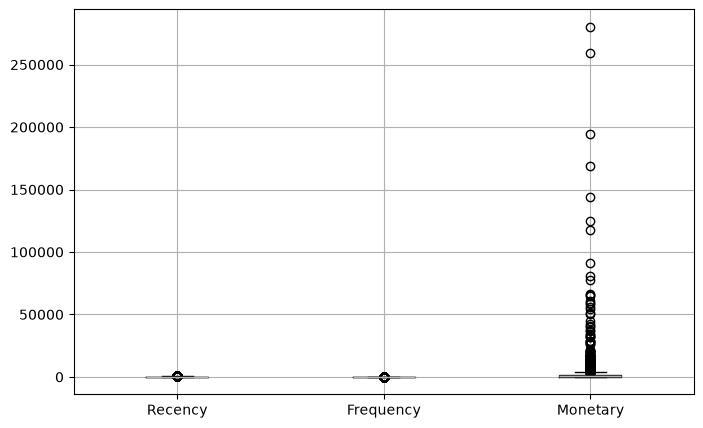

In [49]:
rfm.boxplot(figsize=(8,5))
plt.show()

### boxplot shows many outliers, especially in:

#### Monetary
#### Frequency

#### Example:

- Some customers spent ₹500
- Some customers spent ₹280,206

#### This is actually normal in retail data.

#### Should we remove these outliers?

#### For this project:

-No.

### Reason:

#### Those outliers may be:

- VIP customers
- Bulk buyers
- Business customers
- High-value customers

## Removing them could remove the most important customer segments.

## feature scaling

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled.shape

(4338, 3)

## Why did we do Feature Scaling?

### Before scaling:

#### Recency   max = 373
#### Frequency max = 209
#### Monetary  max = 280206

### Monetary is much larger.

## Without scaling:

## KMeans would mainly focus on Monetary

### After StandardScaler:

#### Recency
#### Frequency
#### Monetary

## all have similar influence.

#  finding the best value of K using the Elbow Method

## Purpose of Elbow Method

### We don't know:

## How many customer groups exist?

### Could be:

- 3 clusters
- 4 clusters
- 5 clusters
- 6 clusters

### The Elbow Method helps us choose the optimal number of clusters

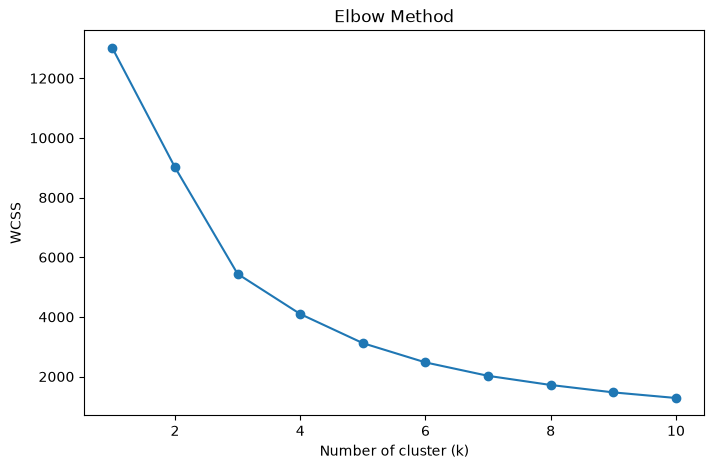

In [51]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of cluster (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#### The Elbow Method is used to determine the optimal number of clusters for K-Means clustering. It calculates the Within Cluster Sum of Squares (WCSS) for different values of K and plots the results. The optimal number of clusters is chosen at the point where the rate of decrease in WCSS starts slowing down, forming an "elbow" shape. In this project, the elbow appears around K=3, suggesting that three customer segments may be an appropriate choice for clustering.

# Train KMeans

In [52]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = kmeans.fit_predict(rfm_scaled)
rfm['Cluster']= clusters

In [53]:
# Check Cluster Distribution
rfm['Cluster'].value_counts()

Cluster
1    3230
0    1082
2      26
Name: count, dtype: int64

In [54]:
#Analyze Clusters
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,246.106285,1.582255,629.663689
1,40.454180,4.672755,1849.670202
2,5.038462,66.423077,85826.078077


#### Business Interpretation
| Cluster   | Meaning                   |
| --------- | ------------------------- |
| Cluster 0 | Inactive / Lost Customers |
| Cluster 1 | Regular Customers         |
| Cluster 2 | VIP Customers             |


# Cluster 0
- Recency   = 246 (long time since purchase)
- Frequency = 1.58
- Monetary  = 629

## Customers haven't purchased recently and spend little.

# Cluster 1
- Recency   = 40
- Frequency = 4.67
- Monetary  = 1849

## Regular active customers.

# Cluster 2
- Recency   = 5
- Frequency = 66
- Monetary  = 85826

## VIP customers.

### K-Means Clustering

#### K-Means is an unsupervised learning algorithm used to group customers with similar purchasing behavior. After selecting the optimal number of clusters using the Elbow Method, the algorithm assigns each customer to a cluster based on their Recency, Frequency, and Monetary values. Customers within the same cluster have similar characteristics, which helps identify groups such as loyal customers, inactive customers, and high-value customers.

# Silhouette Score

## This tells us how good the clustering is.

In [55]:
from sklearn.metrics import silhouette_score
score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.5942233320872992


## Interpretation

| Score Range | Meaning         |
| ----------- | --------------- |
| < 0.25      | Poor clustering |
| 0.25 - 0.50 | Acceptable      |
| 0.50 - 0.70 | Good            |
| > 0.70      | Excellent       |


In [56]:
# trying with k=4
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)
clusters = kmeans.fit_predict(rfm_scaled)
rfm['Cluster']= clusters

In [57]:
from sklearn.metrics import silhouette_score
score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.6162275299061803


In [58]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5,random_state=42,n_init=10)
clusters = kmeans.fit_predict(rfm_scaled)
rfm['Cluster']= clusters

from sklearn.metrics import silhouette_score
score = silhouette_score(rfm_scaled, clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.6165002474679847


In [59]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(rfm_scaled)

rfm['Cluster'] = clusters

In [60]:
print(rfm['Cluster'].value_counts())

rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64


,Recency,Frequency,Monetary
Cluster,,,
0,42.702685,3.682711,1353.625312
1,247.075914,1.552015,478.848773
2,6.384615,82.538462,127187.959231
3,14.500000,22.333333,12690.500392


#### The K-Means algorithm was applied with K = 4 based on the Elbow Method and Silhouette Score analysis. The resulting clusters represent different customer segments based on their Recency, Frequency, and Monetary values.

# Interpretation 
## Cluster 0 – Regular Customers
- Recency ≈ 43 days
- Frequency ≈ 4 purchases
- Monetary ≈ 1354

### These customers purchase relatively recently and spend a moderate amount. They represent the majority of active customers.

## Cluster 1 – Lost / Inactive Customers
- Recency ≈ 247 days
- Frequency ≈ 2 purchases
- Monetary ≈ 479

### These customers have not purchased for a long time and contribute low revenue. Retention campaigns can be targeted toward this segment.

## Cluster 2 – VIP Customers
- Recency ≈ 6 days
- Frequency ≈ 83 purchases
- Monetary ≈ 127,188

### These are the most valuable customers. They purchase frequently, spend the most money, and have purchased recently. Special offers and loyalty programs should be focused on this segment.

## Cluster 3 – Loyal High-Value Customers
- Recency ≈ 15 days
- Frequency ≈ 22 purchases
- Monetary ≈ 12,691

### These customers are highly engaged and generate significant revenue. They represent a strong customer base and can be targeted for premium promotions.

# Save KMeans Model

In [61]:
import joblib 
joblib.dump(kmeans, 'kmeans_customer_segmentation.pkl')

print("Model Saved Successfully")

Model Saved Successfully


In [62]:
joblib.dump(scaler, 'rfm_scaler.pkl')

print("Scaler Saved Successfully")

scaler = joblib.load('rfm_scaler.pkl')

Scaler Saved Successfully


# Hierarchical Clustering

## Build Dendrogram
### Purpose- A dendrogram helps us decide how many clusters may exist in the data.

- A dendrogram is a tree-like diagram used in hierarchical clustering. It shows how observations are merged into clusters at different distance levels. By examining the largest vertical gap, an appropriate number of clusters can be selected.

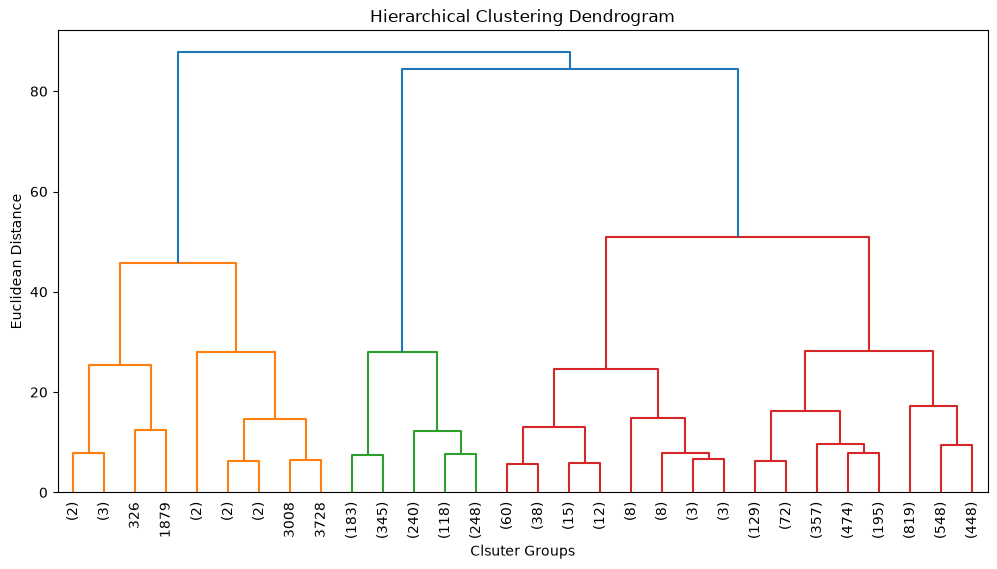

In [63]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
linked = linkage(rfm_scaled, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked,truncate_mode ='lastp',p=30,leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clsuter Groups")
plt.ylabel("Euclidean Distance")
plt.show()

##### The dendrogram visualizes how customer groups are merged during hierarchical clustering. Large vertical distances indicate significant differences between clusters. The dendrogram suggests that the data can be reasonably divided into approximately 3–4 customer segments, which is consistent with the K-Means Elbow Method and Silhouette Score results. Therefore, 4 clusters were selected for further hierarchical clustering analysis.

# Train Hierarchical Clustering

In [64]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

hc_clusters = hc.fit_predict(rfm_scaled)

rfm['HC_Cluster'] = hc_clusters

In [65]:
# Cluster Distribution
print(rfm['HC_Cluster'].value_counts())

HC_Cluster
1    3042
2    1134
3     147
0      15
Name: count, dtype: int64


- The Agglomerative Hierarchical Clustering algorithm divided customers into four segments. Most customers belong to Cluster 1 and Cluster 2, while Cluster 0 contains a very small number of customers with exceptionally high spending and purchase frequency. This indicates the presence of a small group of highly valuable customers.

In [66]:
# Cluster Analysis
rfm.groupby('HC_Cluster')[
    ['Recency','Frequency','Monetary']
].mean()

,Recency,Frequency,Monetary
HC_Cluster,,,
0,5.733333,83.466667,111780.635333
1,40.227482,3.888231,1479.412877
2,240.409171,1.640212,518.617770
3,13.625850,24.435374,14435.461497


#  Cluster Analysis
## Hierarchical Cluster Interpretation
- Cluster 0 – VIP Customers
- Recency ≈ 6 days
- Frequency ≈ 83 purchases
- Monetary ≈ 111,781

### These customers purchase very recently, buy frequently, and contribute the highest revenue. They represent the most valuable customer segment.

- Cluster 1 – Regular Customers
- Recency ≈ 40 days
- Frequency ≈ 4 purchases
- Monetary ≈ 1,479

### These customers are moderately active and generate average revenue. They represent the largest customer segment.

- Cluster 2 – Inactive Customers
- Recency ≈ 240 days
- Frequency ≈ 2 purchases
- Monetary ≈ 519

### These customers have not purchased recently and contribute minimal revenue. They are potential targets for retention campaigns.

- Cluster 3 – Loyal Customers
- Recency ≈ 14 days
- Frequency ≈ 24 purchases
- Monetary ≈ 14,435

### These customers purchase frequently and generate substantial revenue. They are strong candidates for loyalty programs and premium offers.

# Silhouette Score

In [67]:
from sklearn.metrics import silhouette_score

hc_score = silhouette_score(
    rfm_scaled,
    hc_clusters
)

print("Hierarchical Silhouette Score:", hc_score)

Hierarchical Silhouette Score: 0.6077080145270354


### The Hierarchical Clustering model achieved a Silhouette Score of 0.607. This indicates good separation between customer groups and suggests that the identified clusters are meaningful and well-structured. The score is very close to the K-Means result, showing that both algorithms perform similarly on this dataset.

# DBSCAN -Density-Based Spatial Clustering of Applications with Noise

In [68]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=10
)

db_clusters = dbscan.fit_predict(rfm_scaled)

rfm['DBSCAN_Cluster'] = db_clusters

In [69]:
#Check clusters

print(rfm['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    4262
-1      67
 1       9
Name: count, dtype: int64


In [70]:
# Check number of clusters

print("Clusters Found:",
      len(set(db_clusters)) -
      (1 if -1 in db_clusters else 0))

Clusters Found: 2


In [71]:
#DBSCAN often behaves differently from KMeans and Hierarchical.

In [72]:
# Check noise points

print("Noise Points:",
      list(db_clusters).count(-1))

Noise Points: 67


In [73]:
# Cluster analysis

rfm.groupby('DBSCAN_Cluster')[
    ['Recency','Frequency','Monetary']
].mean()

,Recency,Frequency,Monetary
DBSCAN_Cluster,,,
-1,41.716418,40.104478,45258.416418
0,92.507039,3.654388,1336.858239
1,2.777778,30.000000,17467.242222


# Silhouette Score

In [74]:
from sklearn.metrics import silhouette_score

if len(set(db_clusters)) > 1:
    
    score = silhouette_score(
        rfm_scaled,
        db_clusters
    )
    
    print("DBSCAN Silhouette Score:", score)

DBSCAN Silhouette Score: 0.6488035489550034


In [75]:
rfm['DBSCAN_Cluster'].value_counts()

#Clusters Found

#Noise Points

rfm.groupby('DBSCAN_Cluster').mean()

,Recency,Frequency,Monetary,Cluster,HC_Cluster
DBSCAN_Cluster,,,,,
-1,41.716418,40.104478,45258.416418,2.597015,2.089552
0,92.507039,3.654388,1336.858239,0.352886,1.310183
1,2.777778,30.000000,17467.242222,3.000000,3.000000


| Algorithm    | Clusters  | Silhouette Score |
| ------------ | --------- | ---------------- |
| KMeans (K=4) | 4         | **0.616**        |
| Hierarchical | 4         | **0.608**        |
| DBSCAN       | 2 + Noise | **0.649**        |

#### Although DBSCAN achieved the highest Silhouette Score, it identified only two major clusters and a set of noise points. KMeans provided more interpretable customer segments (Inactive, Regular, Loyal, and VIP Customers), making it more suitable for customer segmentation and marketing strategies.

In [76]:
# Create Comparison Table
comparison = {
    'Algorithm':['KMeans','Hierarchical','DBSCAN'],
    'Clusters':[4,4,2],
    'Silhouette Score':[0.616,0.608,0.649]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Algorithm,Clusters,Silhouette Score
0,KMeans,4,0.616
1,Hierarchical,4,0.608
2,DBSCAN,2,0.649


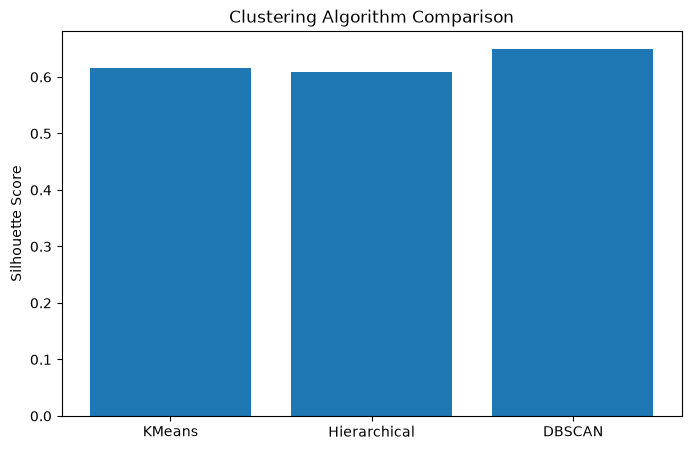

In [77]:
# Create Final Bar Chart
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Algorithm'],
    comparison_df['Silhouette Score']
)

plt.title('Clustering Algorithm Comparison')
plt.ylabel('Silhouette Score')

plt.show()

In [78]:
#Save Models

#I already saved KMeans.

#Also save DBSCAN and Hierarchical:

import joblib

print(joblib.dump(kmeans,'kmeans_model.pkl'))
print(joblib.dump(dbscan,'dbscan_model.pkl'))
print(joblib.dump(scaler,'rfm_scaler.pkl'))

['kmeans_model.pkl']
['dbscan_model.pkl']
['rfm_scaler.pkl']


# Three clustering algorithms were applied to customer segmentation using RFM features. KMeans and Hierarchical Clustering identified four meaningful customer groups, including inactive, regular, loyal, and VIP customers. DBSCAN achieved the highest Silhouette Score (0.649) and successfully identified outlier customers; however, it produced fewer business-oriented segments. Based on interpretability and business value, KMeans was selected as the preferred model for customer segmentation.

# Create Segment Names

In [79]:
segment_map = {
    0: 'Regular Customer',
    1: 'Inactive Customer',
    2: 'VIP Customer',
    3: 'Loyal Customer'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

rfm.head()

,Recency,Frequency,Monetary,Cluster,HC_Cluster,DBSCAN_Cluster,Segment
CustomerID,,,,,,,
12346.0,325,1,77183.60,3,3,-1,Loyal Customer
12347.0,1,7,4310.00,0,1,0,Regular Customer
12348.0,74,4,1797.24,0,1,0,Regular Customer
12349.0,18,1,1757.55,0,1,0,Regular Customer
12350.0,309,1,334.40,1,2,0,Inactive Customer


# Create Business Actions

In [80]:
recommendation_map = {
    'VIP Customer':'Provide premium membership and exclusive offers',
    'Loyal Customer':'Offer loyalty rewards and referral programs',
    'Regular Customer':'Provide product recommendations and bundle offers',
    'Inactive Customer':'Send retention campaigns and discount coupons'
}

rfm['Recommendation'] = rfm['Segment'].map(recommendation_map)

In [81]:
# Create Executive Summary Table
segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

segment_summary

,Recency,Frequency,Monetary
Segment,,,
Inactive Customer,247.075914,1.552015,478.848773
Loyal Customer,14.500000,22.333333,12690.500392
Regular Customer,42.702685,3.682711,1353.625312
VIP Customer,6.384615,82.538462,127187.959231


In [82]:
print(df.shape)
print(rfm.shape)

(392692, 9)
(4338, 8)


In [83]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,HC_Cluster,DBSCAN_Cluster,Segment,Recommendation
CustomerID,,,,,,,,
12346.0,325,1,77183.60,3,3,-1,Loyal Customer,Offer loyalty rewards and referral programs
12347.0,1,7,4310.00,0,1,0,Regular Customer,Provide product recommendations and bundle offers
12348.0,74,4,1797.24,0,1,0,Regular Customer,Provide product recommendations and bundle offers
12349.0,18,1,1757.55,0,1,0,Regular Customer,Provide product recommendations and bundle offers
12350.0,309,1,334.40,1,2,0,Inactive Customer,Send retention campaigns and discount coupons


In [84]:
# Create Final Business Dataset
rfm_final = rfm.copy()

rfm_final['Segment'] = rfm_final['Cluster'].map({
    0:'Regular Customer',
    1:'Inactive Customer',
    2:'VIP Customer',
    3:'Loyal Customer'
})

rfm_final.head()

,Recency,Frequency,Monetary,Cluster,HC_Cluster,DBSCAN_Cluster,Segment,Recommendation
CustomerID,,,,,,,,
12346.0,325,1,77183.60,3,3,-1,Loyal Customer,Offer loyalty rewards and referral programs
12347.0,1,7,4310.00,0,1,0,Regular Customer,Provide product recommendations and bundle offers
12348.0,74,4,1797.24,0,1,0,Regular Customer,Provide product recommendations and bundle offers
12349.0,18,1,1757.55,0,1,0,Regular Customer,Provide product recommendations and bundle offers
12350.0,309,1,334.40,1,2,0,Inactive Customer,Send retention campaigns and discount coupons


In [85]:
rfm_final.to_csv('customer_segments.csv')

In [86]:
print('hello, world!')

hello, world!
